# Customer Segmentation Analysis

## Oasis Infobyte – Data Analytics Internship

### Task 2: Customer Segmentation Analysis

This project segments customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering.

## Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## Load the Dataset

In [35]:
file_path = "../Data/Online Retail.xlsx"

df = pd.read_excel(file_path)

## Initial Data Inspection

In [36]:
df.shape

(541909, 8)

In [37]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [38]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [39]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [40]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [42]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(5268)

## Descriptive Statistics

In [44]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


## Data Cleaning

In [45]:
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

## Feature Engineering

In [46]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [47]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## RFM Analysis

In [48]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Descriptive Statistics

In [49]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


## Customer Purchase Metrics

In [50]:
average_purchase_value = df.groupby("InvoiceNo")["TotalPrice"].sum().mean()
average_purchase_frequency = rfm["Frequency"].mean()
average_customer_lifetime_value = rfm["Monetary"].mean()

pd.DataFrame({
    "Metric": [
        "Average Purchase Value",
        "Average Purchase Frequency",
        "Average Customer Lifetime Value"
    ],
    "Value": [
        average_purchase_value,
        average_purchase_frequency,
        average_customer_lifetime_value
    ]
})

,Metric,Value
0,Average Purchase Value,479.560160
1,Average Purchase Frequency,4.272015
2,Average Customer Lifetime Value,2048.688081


## RFM Distribution

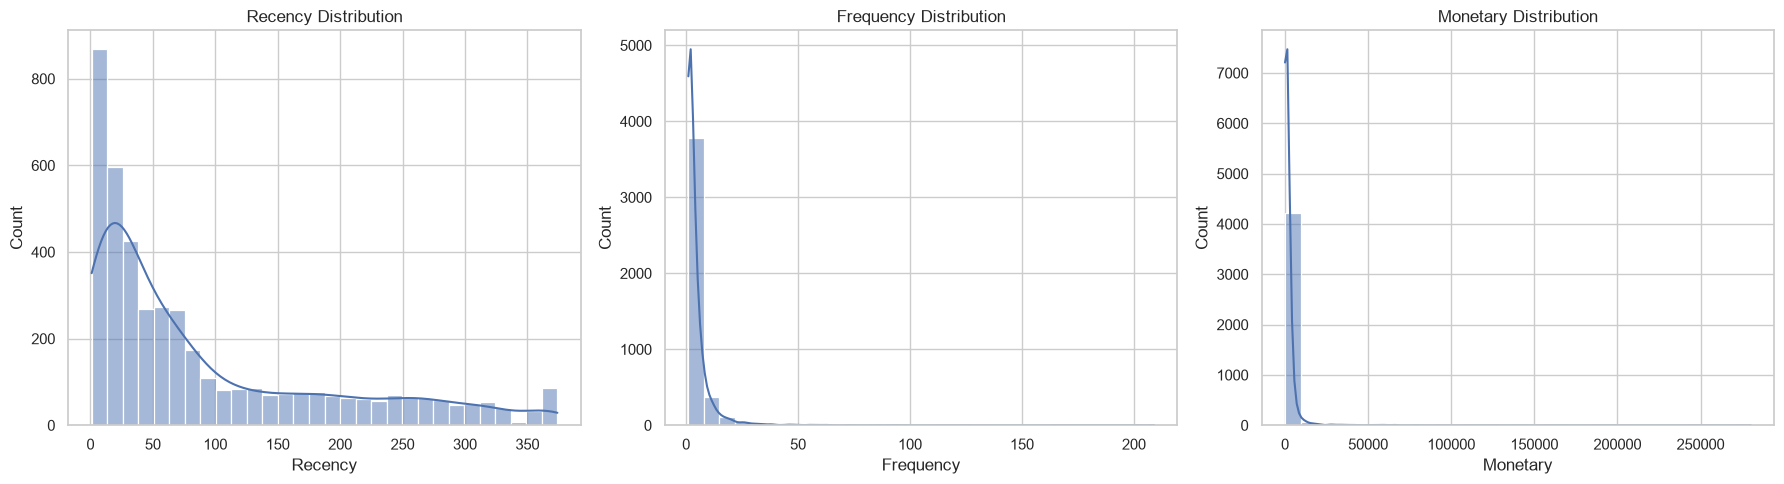

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

## Feature Scaling

In [52]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


## Elbow Method

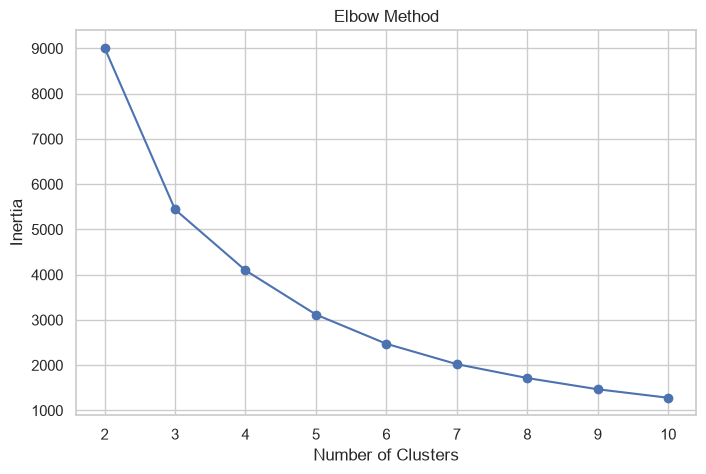

In [53]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## K-Means Clustering

In [54]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## Cluster Profiling

In [55]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.92,3.65,1333.13
1,248.47,1.55,478.65
2,6.50,120.50,55099.49
3,15.67,21.29,12813.94
4,7.67,42.83,190808.54


## Customer Count by Cluster

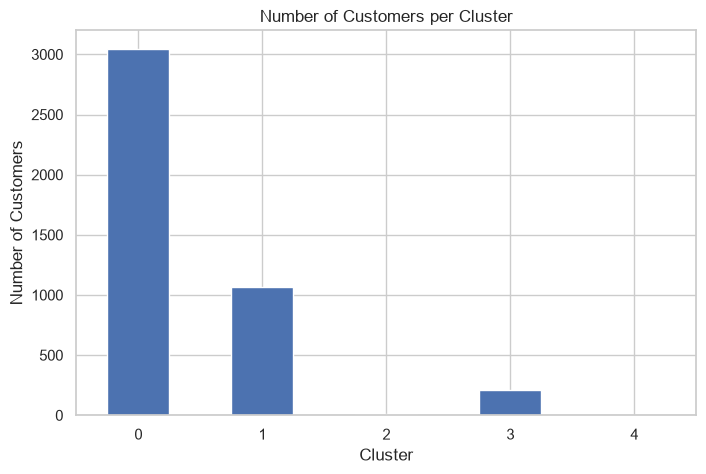

In [56]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Cluster")
plt.xticks(rotation=0)
plt.show()

## Cluster Visualization


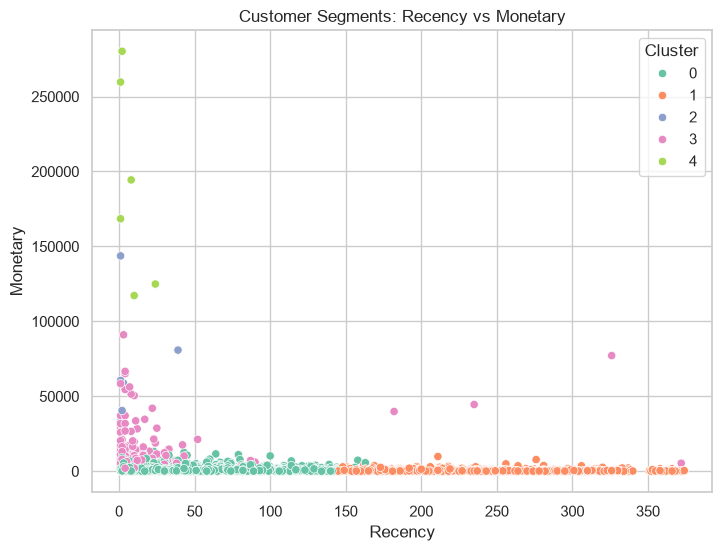

In [57]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

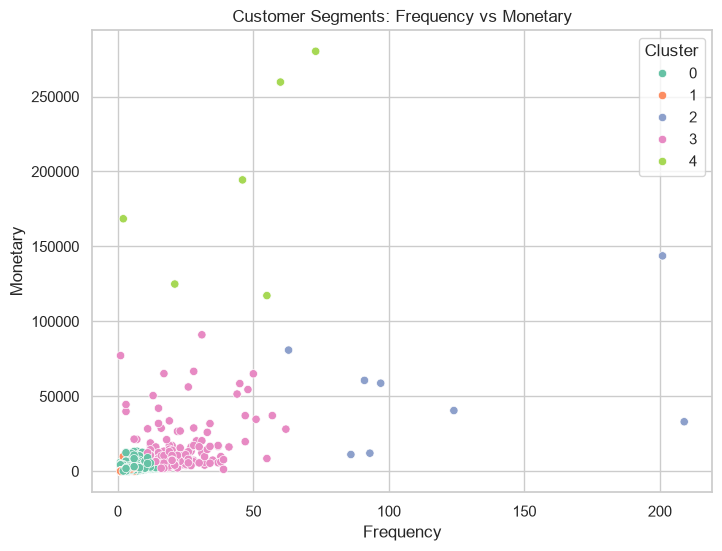

In [58]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

## Cluster Characteristics

In [59]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.92,3.65,1333.13
1,248.47,1.55,478.65
2,6.50,120.50,55099.49
3,15.67,21.29,12813.94
4,7.67,42.83,190808.54


## Customer Segment Interpretation

## Marketing Recommendations

Different marketing strategies can be applied to each customer segment based on their purchasing behaviour.

- **Regular Customers:** Use personalized offers and product recommendations to encourage more frequent purchases.
- **At-Risk / Lost Customers:** Use reactivation campaigns, special discounts, and reminders to encourage customers to return.
- **High-Value Loyal Customers:** Provide loyalty rewards, exclusive offers, and early access to new products.
- **Loyal Customers:** Encourage repeat purchases through loyalty programs and personalized promotions.
- **VIP Customers:** Focus on retention through premium services, exclusive benefits, and personalized experiences.

## Key Insights

The clustering analysis identifies clear differences in customer purchasing behaviour based on Recency, Frequency, and Monetary value. 
- A small group of customers contributes very high purchase frequency and spending, making them important high-value segments. 
- Another group shows low engagement and long periods since their last purchase, indicating a need for customer reactivation strategies. 
- The remaining segments represent regular and loyal customers who can be developed through targeted offers and loyalty programs.

## Conclusion


The customer segmentation analysis successfully grouped customers into five distinct segments using Recency, Frequency, and Monetary value. The analysis shows that customers differ significantly in their purchasing frequency, spending behaviour, and recency of purchase. These segments can help the business focus on customer retention, reactivation, loyalty building, and targeted marketing strategies.

## Recommendations

- Focus on retaining VIP and high-value loyal customers through exclusive rewards, personalized offers, and premium benefits.
- Launch targeted reactivation campaigns for at-risk or lost customers using discounts, reminders, and relevant product recommendations.
- Develop regular and loyal customers through loyalty programs and personalized promotions to increase purchase frequency and customer value.